**Project Overview**

SentinelNet is an AI-powered Network Intrusion Detection System (NIDS) that detects and classifies malicious network traffic using advanced machine learning algorithms for enhanced cybersecurity.


## **MILESTONE - 1**

Step-1 : Dataset Acquisition and Loading

The dataset used in this project is CICIDS2017, obtained from the official source of the Canadian Institute for Cybersecurity.
Dataset: https://www.unb.ca/cic/datasets/ids-2017.html


**Importing necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Wednesday-workingHours dataset file from CICIDS2017

In [ ]:
file_path = "/content/drive/MyDrive/data/Wednesday-workingHours.pcap_ISCX.csv"

**Exploratory Data Analysis (EDA)**
# Step-2 : Dataset Loading and Initial Exploration
In this step, we load the selected dataset (Wednesday-workingHours.pcap_ISCX.csv) using Pandas and perform an initial look at its structure.


In [ ]:
import pandas as pd

df = pd.read_csv(file_path)
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (692703, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80           38308                   1   
1                389             479                  11   
2                 88            1095                  10   
3                389           15206                  17   
4                 88            1092                   9   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        5                          172   
2                        6                         3150   
3                       12                         3452   
4                        6                         3150   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             6                       6   
1                           326                      79   
2                          3150                    1575   
3                   

### Explanation
- **pd.read_csv()** is used to load the dataset from the given file path.  
- **df.shape** shows the number of rows and columns.  
- **df.head()** displays the first five records to get an overview of the dataset structure.


## Step-2.1 : Display Column Names
We check all the column names in the dataset to understand the available features and their structure.


In [ ]:
print("\nColumn names:\n", df.columns.tolist())


Column names:
 [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Cou

### Explanation
- **df.columns.tolist()** converts all column headers into a list format.  
- This helps identify feature names and check for any unwanted spaces, special characters, or duplicated column names.


## Step-2.2 : Check Data Types of Columns
We examine the data types of all columns to identify numerical and categorical features for further analysis.


In [ ]:
print("\nData types:\n", df.dtypes.value_counts())
print("\nDetailed types:\n", df.dtypes)


Data types:
 int64      54
float64    24
object      1
Name: count, dtype: int64

Detailed types:
  Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
 Label                          object
Length: 79, dtype: object


### Explanation
- **df.dtypes.value_counts()** shows how many columns belong to each data type (e.g., int, float, object).  
- **df.dtypes** displays the specific data type for every column individually.  
- Understanding data types is essential for selecting proper preprocessing, encoding, and analysis methods.


## Step-2.3 : Dataset Information Summary
We display a concise summary of the dataset to understand column data types, non-null counts, and memory usage.


In [ ]:
print("\nInfo Summary:")
print(df.info())



Info Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             692703 non-null  int64  
 1    Flow Duration                692703 non-null  int64  
 2    Total Fwd Packets            692703 non-null  int64  
 3    Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets   692703 non-null  int64  
 5    Total Length of Bwd Packets  692703 non-null  int64  
 6    Fwd Packet Length Max        692703 non-null  int64  
 7    Fwd Packet Length Min        692703 non-null  int64  
 8    Fwd Packet Length Mean       692703 non-null  float64
 9    Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max         692703 non-null  int64  
 11   Bwd Packet Length Min        692703 non-null  int64  
 12   Bwd Packet Length Mean      

### Explanation
- **df.info()** provides an overview of the dataset, including column names, data types, and non-null value counts.  
- This helps identify missing data, data type mismatches, and overall dataset structure before preprocessing.


## Step-2.4 : Basic Statistical Summary
We generate descriptive statistics for all numerical features to understand their distribution and key metrics.


In [ ]:
print("\nBasic Statistics (numeric features):\n", df.describe().T)


Basic Statistics (numeric features):
                                 count          mean           std  min    25%  \
 Destination Port            692703.0  5.686869e+03  1.572742e+04  0.0   53.0   
 Flow Duration               692703.0  2.800168e+07  4.276680e+07 -1.0  201.0   
 Total Fwd Packets           692703.0  9.556261e+00  7.471978e+02  1.0    2.0   
 Total Backward Packets      692703.0  1.021408e+01  9.842046e+02  0.0    1.0   
Total Length of Fwd Packets  692703.0  5.550930e+02  6.163663e+03  0.0   12.0   
...                               ...           ...           ...  ...    ...   
 Active Min                  692703.0  6.315186e+04  6.051023e+05  0.0    0.0   
Idle Mean                    692703.0  2.211122e+07  3.812415e+07  0.0    0.0   
 Idle Std                    692703.0  4.743744e+05  4.488512e+06  0.0    0.0   
 Idle Max                    692703.0  2.252174e+07  3.848292e+07  0.0    0.0   
 Idle Min                    692703.0  2.173373e+07  3.807725e+07  0.0

### Explanation
- **df.describe()** provides key statistical measures such as mean, standard deviation, minimum, and maximum values.  
- **.T** (transpose) is used to display the summary vertically for better readability.  
- This helps detect potential outliers, skewed distributions, and feature scale differences.


 Data Cleaning and Preprocessing




 ## Step-2.5 : Check for Missing Values
We check for missing or null values in the dataset to ensure data quality before preprocessing.


In [ ]:
print("\nMissing values per column:\n", df.isnull().sum())
print("\nAny NaN present? ", df.isnull().values.any())



Missing values per column:
  Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

Any NaN present?  True


### Explanation
- **df.isnull().sum()** counts the total number of missing (NaN) values in each column.  
- **df.isnull().values.any()** returns `True` if any NaN value is present in the dataset.  
- Identifying missing values early helps decide whether to remove or impute them during data cleaning.


## Step-2.6 : Visualize Missing Values using Heatmap
We use a heatmap to visually inspect the distribution of missing values across the dataset.


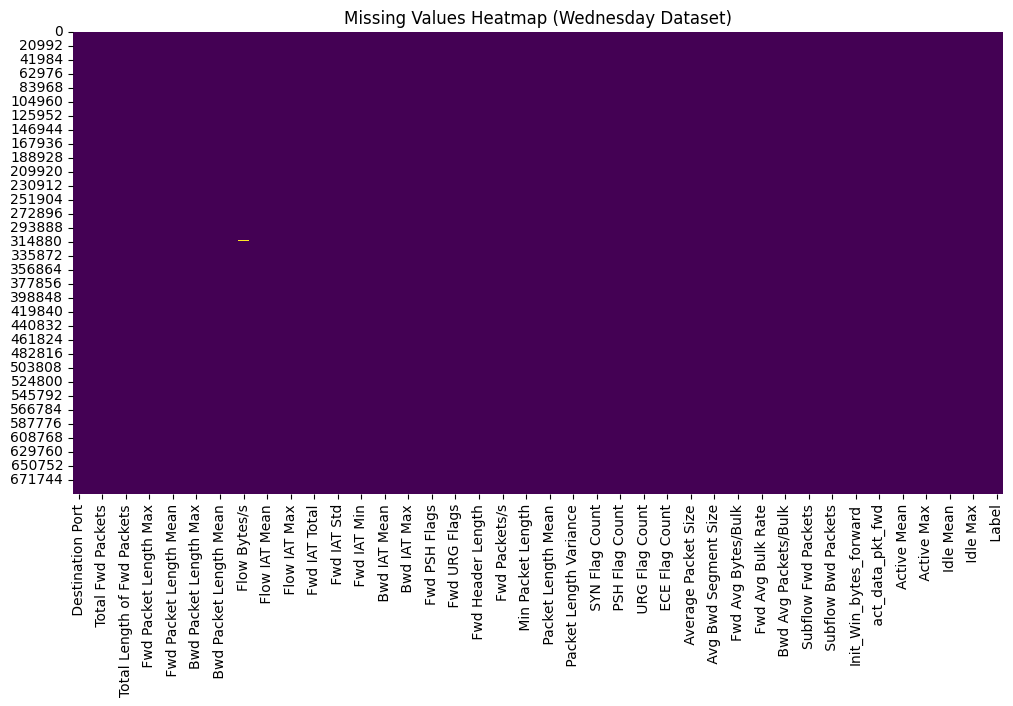

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Wednesday Dataset)")
plt.show()


### Explanation
- **sns.heatmap(df.isnull())** highlights cells with missing values, helping to identify patterns of data absence.  
- The **'viridis'** color map provides a clear visual contrast.  
- This visualization makes it easier to decide if specific columns or rows should be dropped or imputed.


## Step-2.7 : Handle Duplicate Records
We check for duplicate rows in the dataset and remove them to ensure data integrity and prevent model bias.


In [ ]:
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()






Duplicate Rows: 81909


### Explanation
- **df.duplicated().sum()** counts how many duplicate records exist in the dataset.  
- **df.drop_duplicates()** removes all duplicate entries to ensure that each record is unique.  
- Removing duplicates helps improve model performance and avoids redundant data influencing the analysis.


## Step-2.8 : Verify Duplicate Records Before Cleaning
Before removing duplicates, we check the total number of rows and the count of duplicate entries for reference.


In [ ]:
print("Total rows before cleaning:", df.shape[0])
print("Duplicate rows:", df.duplicated().sum())


Total rows before cleaning: 610794
Duplicate rows: 0


### Explanation
- **df.shape[0]** returns the total number of rows in the dataset before any cleaning operations.  
- **df.duplicated().sum()** shows how many duplicate records exist.  
- This helps to document the dataset size before removing redundant data for better comparison later.


## Step-2.9 : Remove Irrelevant and Constant Features
We remove unnecessary and constant columns that do not contribute meaningful information to the model.


In [ ]:

irrelevant_cols = [
    ' Fwd Header Length.1',
    ' Packet Length Variance'
]


constant_cols = [col for col in df.columns if df[col].nunique() <= 1]


df.drop(columns=irrelevant_cols + constant_cols, inplace=True, errors="ignore")

print("Dropped columns:", irrelevant_cols + constant_cols)
print("Remaining columns:", df.shape[1])


Dropped columns: [' Fwd Header Length.1', ' Packet Length Variance', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' CWE Flag Count', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Remaining columns: 67


### Explanation
- **irrelevant_cols** contains predefined columns that are either duplicates or not useful for analysis.  
- **constant_cols** identifies columns with the same value throughout, offering no variance for model learning.  
- **df.drop()** removes these columns from the dataset.  
- Cleaning out such features improves model efficiency and reduces noise.


## Step-2.10 : Correlation Heatmap (Numeric Features Only)
We visualize the relationships between numeric features to identify highly correlated variables.


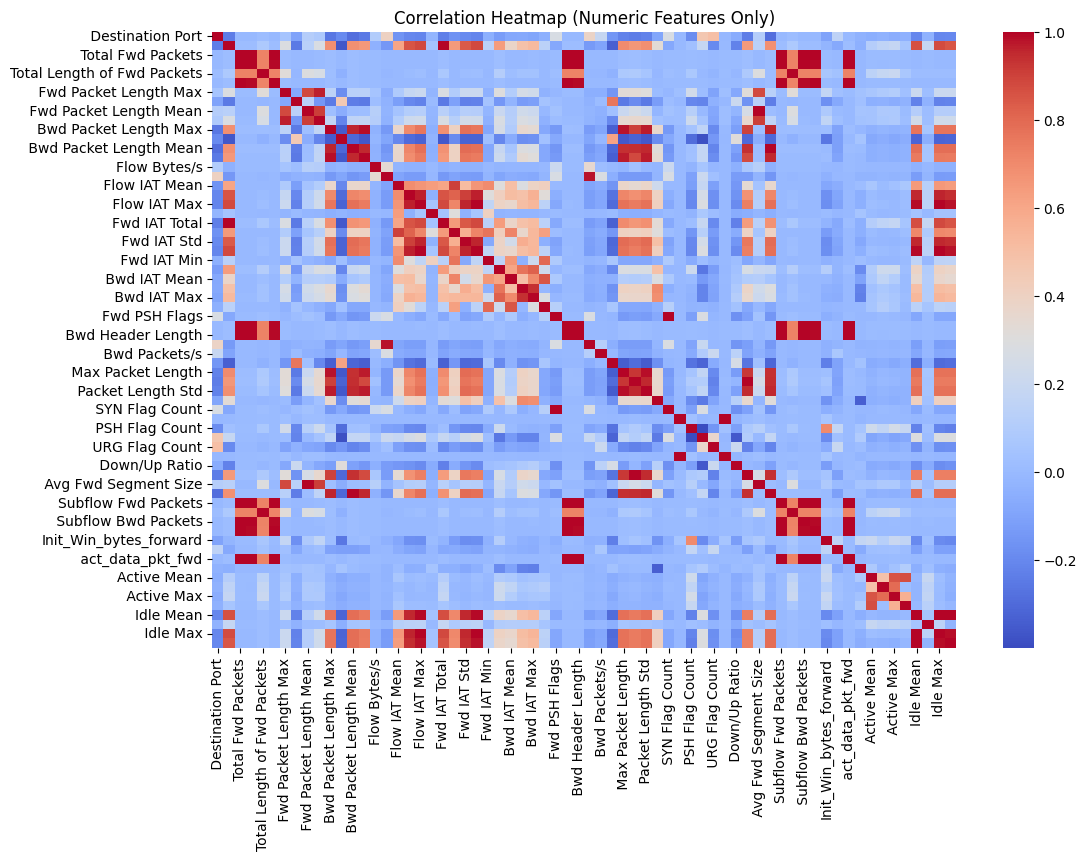

In [ ]:

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


### Explanation
- **numeric_df** filters the dataset to include only numeric columns.  
- **numeric_df.corr()** computes pairwise correlations between numeric features.  
- **sns.heatmap()** visualizes these correlations, with colors indicating the strength and direction:  
  - Blue → Negative correlation  
  - Red → Positive correlation  
- Inspecting correlations helps identify redundant features and potential multicollinearity, guiding feature selection for modeling.


## Step-2.11 : Identify Highly Correlated Feature Pairs
We detect numeric feature pairs with high correlation to help reduce redundancy and multicollinearity.


In [ ]:
print("\nHigh Correlation Pairs:")


numeric_df = df.select_dtypes(include=[np.number])


corr_matrix = numeric_df.corr().abs()


threshold = 0.85
high_corr = np.where(corr_matrix > threshold)
high_corr = [
    (corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x,y])
    for x, y in zip(*high_corr)
    if x != y and x < y
]

print(high_corr)



High Correlation Pairs:
[(' Flow Duration', ' Flow IAT Std', np.float64(0.8526973575817501)), (' Flow Duration', ' Flow IAT Max', np.float64(0.8809122148080017)), (' Flow Duration', 'Fwd IAT Total', np.float64(0.9992268314490031)), (' Flow Duration', ' Fwd IAT Max', np.float64(0.880803447958416)), (' Flow Duration', 'Idle Mean', np.float64(0.8685338987545531)), (' Flow Duration', ' Idle Max', np.float64(0.8790504268864937)), (' Flow Duration', ' Idle Min', np.float64(0.8516774724373036)), (' Total Fwd Packets', ' Total Backward Packets', np.float64(0.9989001864630364)), (' Total Fwd Packets', ' Total Length of Bwd Packets', np.float64(0.9958744921755904)), (' Total Fwd Packets', ' Fwd Header Length', np.float64(0.9997684875984317)), (' Total Fwd Packets', ' Bwd Header Length', np.float64(0.99882419245703)), (' Total Fwd Packets', 'Subflow Fwd Packets', np.float64(1.0)), (' Total Fwd Packets', ' Subflow Bwd Packets', np.float64(0.9989001864630364)), (' Total Fwd Packets', ' Subflow Bwd

### Explanation
- **corr_matrix** stores absolute correlations between numeric features.  
- **threshold = 0.85** filters for very strong correlations.  
- **np.where(corr_matrix > threshold)** finds indices of highly correlated pairs.  
- **x != y and x < y** ensures we avoid duplicate or self-correlations.  
- The resulting **high_corr** list shows feature pairs that might be redundant, helping guide feature removal or dimensionality reduction for modeling.


## Step-2.12 : Outlier Detection Using Boxplot
We visualize the distribution of numeric features and detect potential outliers.


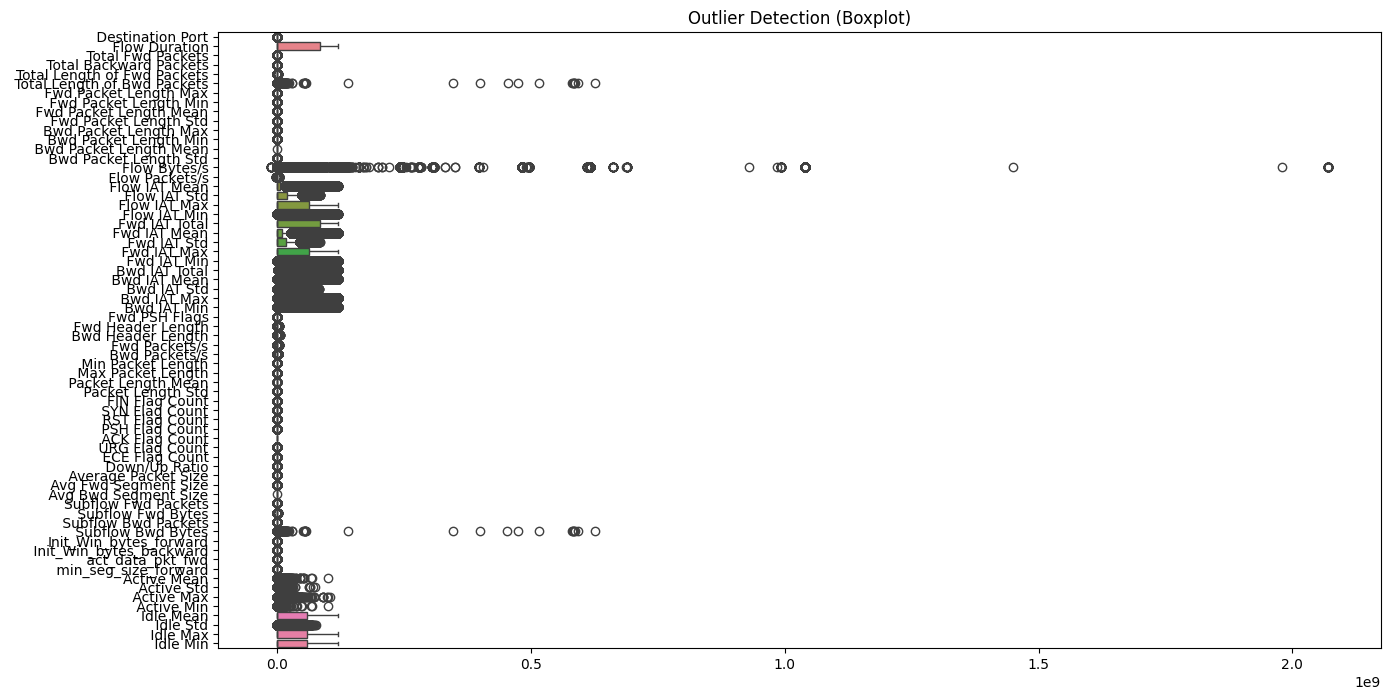

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 8))
sns.boxplot(data=numeric_df, orient="h")
plt.title("Outlier Detection (Boxplot)")
plt.show()

### Explanation
- **numeric_df** ensures only numeric columns are used for plotting.  
- **sns.boxplot(..., orient="h")** displays each numeric feature horizontally for easier readability.  
- Boxplots show:  
  - **Median (center line)**  
  - **Interquartile range (IQR) as box**  
  - **Whiskers** indicating variability outside the upper and lower quartiles  
  - **Outliers** as points outside the whiskers  
- This helps identify extreme values that may skew analysis or modeling.


## Step-2.13 : Detect Outliers Programmatically Using Z-Score
We identify extreme values in numeric features using the Z-score method, which helps in quantifying outliers for potential removal.


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

numeric_df = df.select_dtypes(include=[np.number])
numeric_clean = numeric_df.dropna(axis=1)

z_scores = np.abs(stats.zscore(numeric_clean))
outlier_counts = (z_scores > 3).sum(axis=0)

outlier_counts = pd.Series(outlier_counts, index=numeric_clean.columns)
print(outlier_counts.sort_values(ascending=False).head(15))


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1158: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


 URG Flag Count             44559
 Bwd IAT Max                32699
 Bwd IAT Std                28832
 SYN Flag Count             26501
Fwd PSH Flags               26501
 Init_Win_bytes_backward    18493
 Destination Port           16284
Fwd Packets/s               15307
 Active Max                 10240
 Bwd IAT Mean               10144
 Max Packet Length           9744
Init_Win_bytes_forward       9730
Bwd Packet Length Max        9490
 Bwd IAT Min                 9313
 Fwd Packet Length Max       8839
dtype: int64


### Explanation
- **stats.zscore()** standardizes each numeric feature, converting values into how many standard deviations they are from the mean.  
- **Z-score > 3** is a common threshold to define outliers.  
- **(z_scores > 3).sum(axis=0)** counts the number of extreme values in each feature.  
- Sorting and displaying the top 15 helps focus on features with the most significant outlier presence.  
- This quantitative approach complements the visual inspection from boxplots and aids in data cleaning or transformation decisions.


## Step-2.14 : Feature Importance Using Random Forest
We use a Random Forest Classifier to rank features by importance, helping identify which variables contribute most to the model's predictions.



Top 15 Important Features:
  Bwd Packet Length Mean         0.119917
 Packet Length Std              0.098131
 Bwd Packet Length Std          0.085111
 Avg Bwd Segment Size           0.082951
Bwd Packet Length Max           0.072505
 Average Packet Size            0.064354
 Max Packet Length              0.061039
 Packet Length Mean             0.035312
 Idle Max                       0.026182
Idle Mean                       0.025115
 Total Length of Bwd Packets    0.024290
 Destination Port               0.023320
 Subflow Bwd Bytes              0.022261
 Fwd IAT Max                    0.019223
 Fwd IAT Std                    0.015393
dtype: float64

Least 15 Important Features:
 Active Mean               1.230363e-03
 Idle Std                 1.182439e-03
 Bwd IAT Max              1.164605e-03
 Bwd Packet Length Min    1.026046e-03
 Active Std               1.006131e-03
 URG Flag Count           9.500071e-04
 PSH Flag Count           8.135224e-04
Bwd IAT Total             7.740419e-0

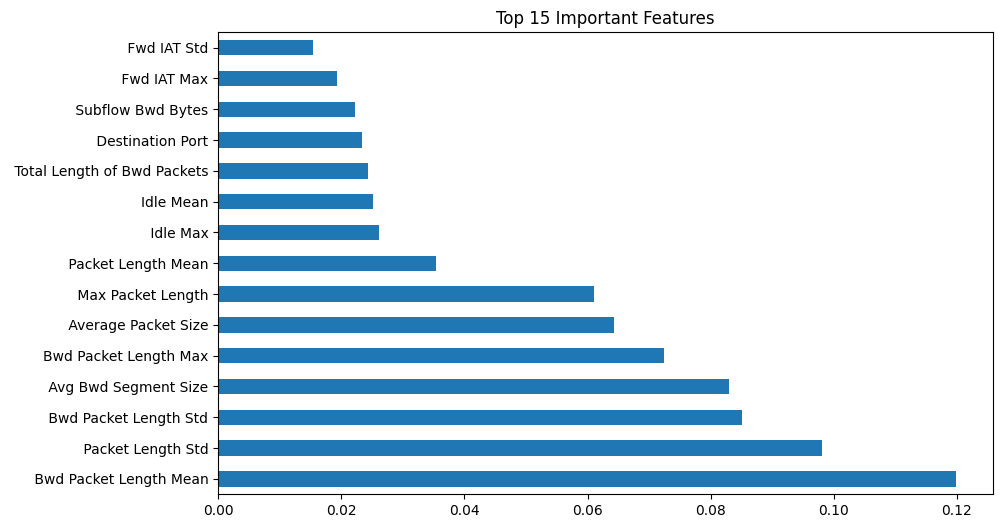

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

X = df.drop(columns=[' Label'])
y = df[' Label']
y = y.apply(lambda x: 0 if x == "BENIGN" else 1)

X = pd.get_dummies(X, drop_first=True)


X = X.drop(columns=['Flow Bytes/s', ' Flow Packets/s'], errors='ignore')

model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
important_features = importances.sort_values(ascending=False)

print("\nTop 15 Important Features:\n", important_features.head(15))
print("\nLeast 15 Important Features:\n", important_features.tail(15))

important_features.head(15).plot(kind='barh', figsize=(10,6))
plt.title("Top 15 Important Features")
plt.show()


### Explanation
- **RandomForestClassifier** estimates feature importance by measuring how much each feature reduces impurity in decision trees.  
- **One-hot encoding** converts categorical features into numeric format suitable for the model.  
- **important_features.sort_values()** ranks features from most to least important.  
- **Bar plot** visually highlights the top features contributing to the model’s prediction.  
- This process helps with **feature selection**, potentially reducing dimensionality and improving model efficiency.


 Feature Engineering and Selection
## Step-2.15 : Identify Categorical and Numerical Features
We separate the dataset into categorical and numerical features, which is essential for applying appropriate preprocessing techniques.


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nCategorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)



Categorical Features: [' Label']
Numerical Features: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag Count', ' ECE Flag Count', 

### Explanation
- **categorical_cols** includes all columns with data type `object` or `category`, which typically require encoding before modeling.  
- **numerical_cols** includes all numeric columns, which can be directly used for modeling or scaled if needed.  
- Separating features ensures the **correct preprocessing steps** are applied to each type (e.g., one-hot encoding for categorical, normalization for numeric).  
- This step is critical for building a clean and robust machine learning pipeline.


## Step-2.16 : Encode Categorical Features
We convert categorical features into numeric format using one-hot encoding, making the dataset compatible with machine learning models.


In [ ]:

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape after Encoding:", df_encoded.shape)



Shape after Encoding: (610794, 71)


### Explanation
- **pd.get_dummies()** converts each categorical variable into multiple binary columns (0 or 1).  
- **drop_first=True** avoids multicollinearity by dropping the first category of each feature.  
- The resulting **df_encoded** is fully numeric and ready for modeling.  
- Encoding categorical features ensures that machine learning algorithms can interpret these variables correctly.


## Step-2.17 : Visualize Feature and Label Distributions
We explore the distributions of numeric features and the target variable to understand dataset balance and variability.


```
# This is formatted as code
```



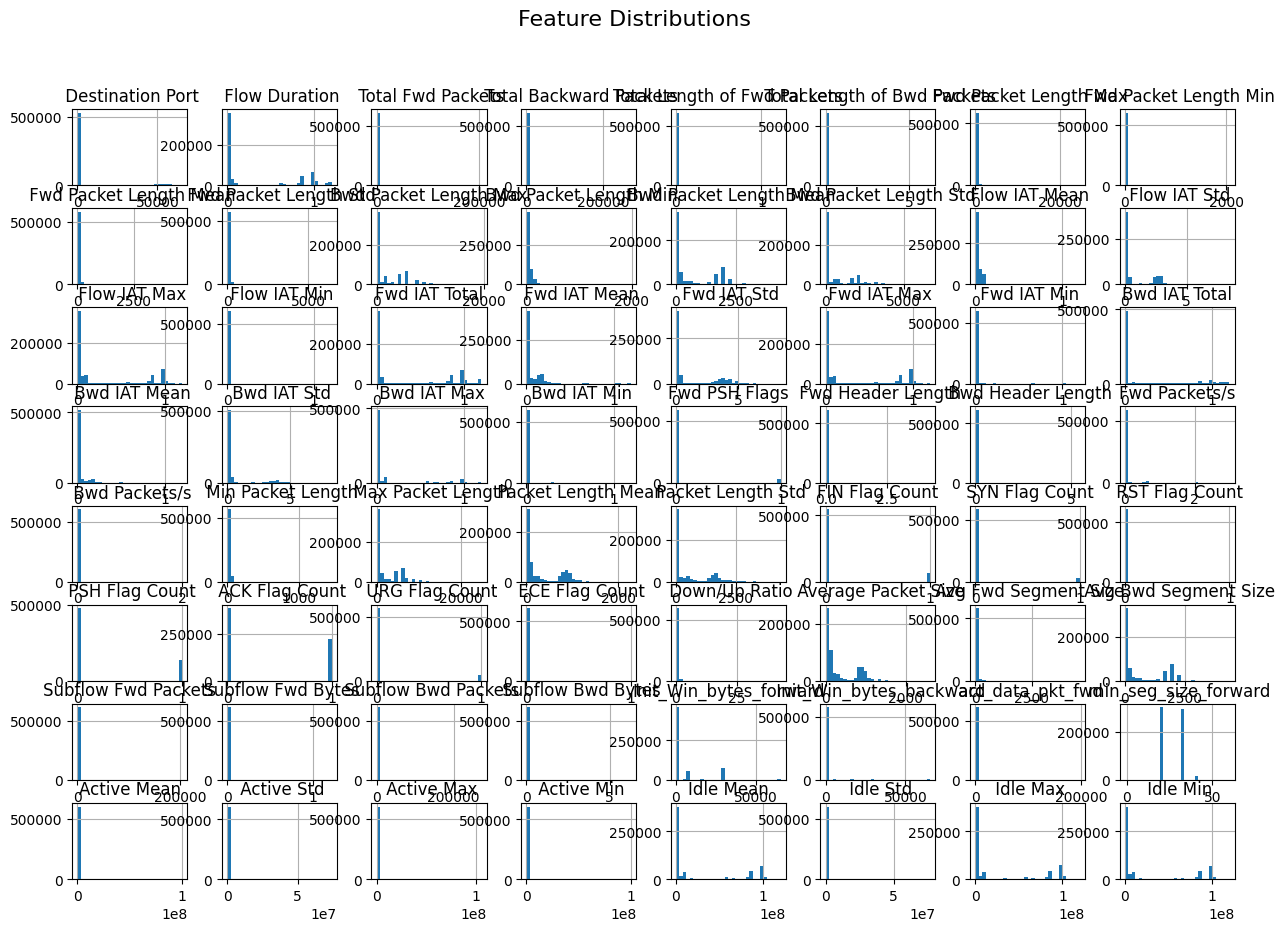

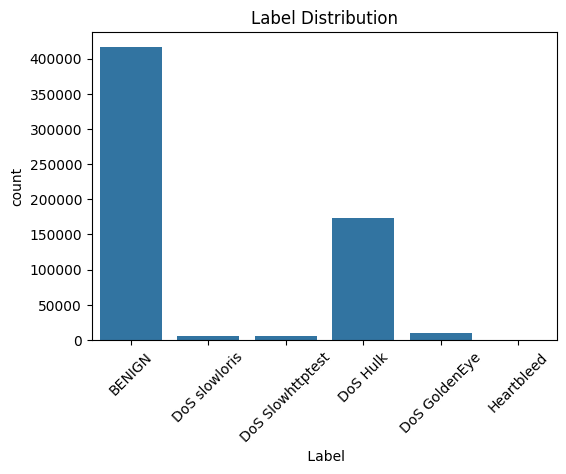

In [ ]:
df_encoded = df_encoded.drop(columns=['Flow Bytes/s', ' Flow Packets/s'], errors='ignore')

df_encoded.hist(figsize=(15,10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()



plt.figure(figsize=(6,4))
sns.countplot(x=df[' Label'])
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.show()


### Explanation
- **df_encoded.hist()** shows the frequency distribution of numeric features, helping identify skewness or unusual patterns.  
- **sns.countplot()** visualizes the distribution of the target variable (`Label`) to check for class imbalance.  
- Dropping columns like `'Flow Bytes/s'` or `' Flow Packets/s'` ensures cleaner visualization and avoids redundancy.  
- Understanding feature and label distributions aids in **data preprocessing, balancing classes, and choosing suitable modeling strategies**.


## Step-2.18 : Save Cleaned and Encoded Dataset
We save the fully cleaned and preprocessed dataset to a CSV file for future modeling and analysis.


In [ ]:

df_encoded.to_csv("cleaned_encoded_dataset.csv", index=False)
print("✅ Cleaned & encoded dataset saved as cleaned_encoded_dataset.csv")


✅ Cleaned & encoded dataset saved as cleaned_encoded_dataset.csv


### Explanation
- **df_encoded.to_csv()** writes the cleaned and fully numeric dataset to a CSV file.  
- **index=False** prevents saving the row indices, keeping the CSV clean.  
- Saving the dataset ensures that all preprocessing, encoding, and cleaning steps are preserved and can be easily reused for modeling or sharing.


## Step-2.19 : Analyze Top 15 Important Features
We focus on the most important features identified by the Random Forest model and explore their distributions, outliers, correlations, and relationship with the target variable.


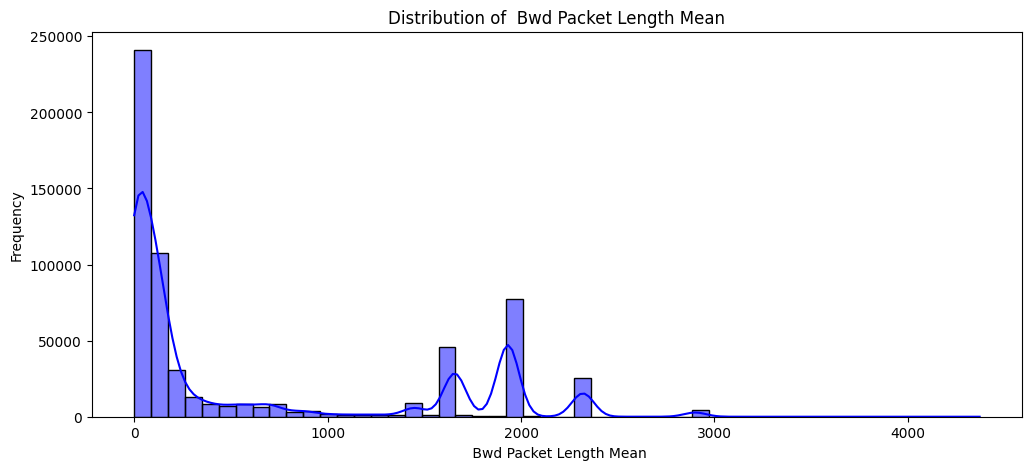

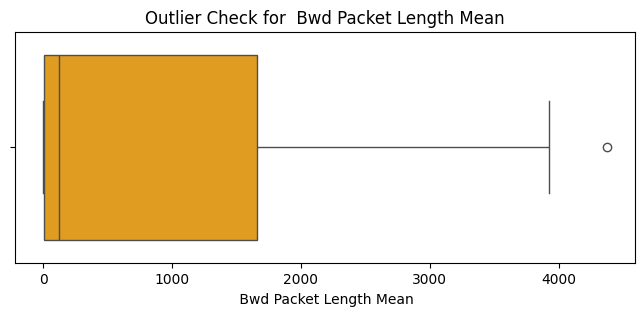

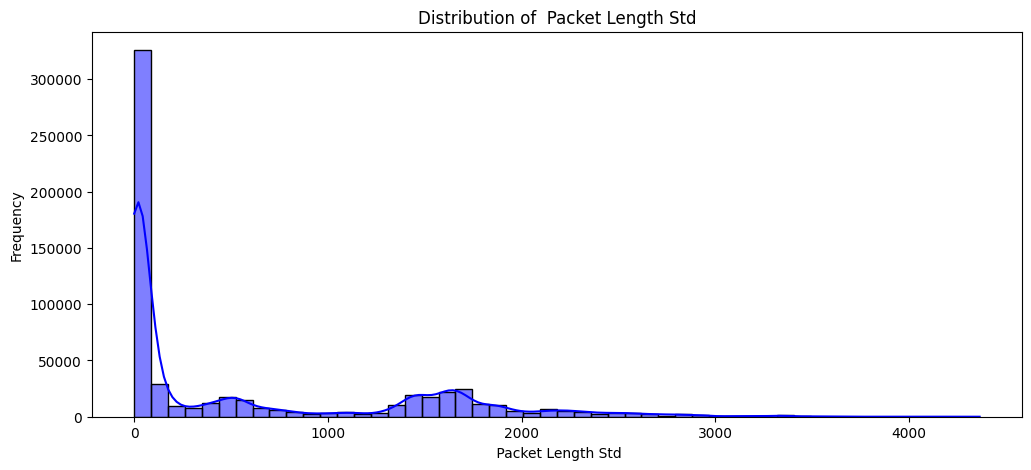

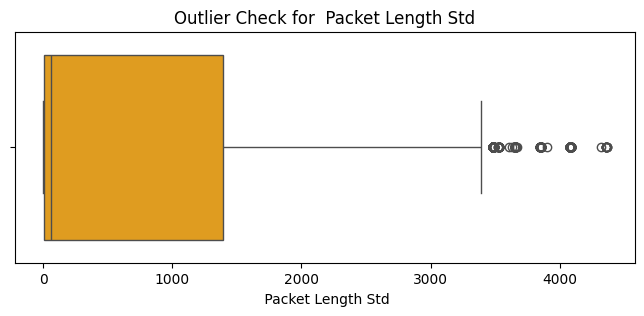

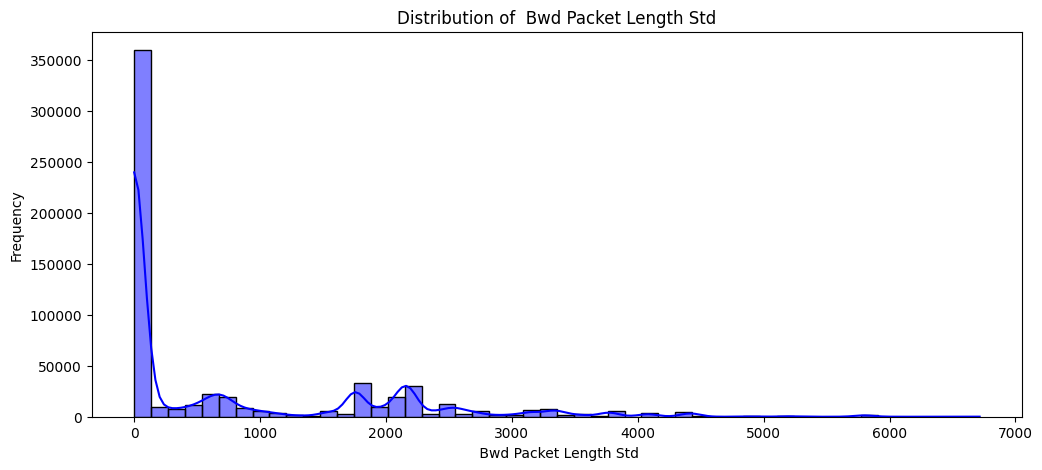

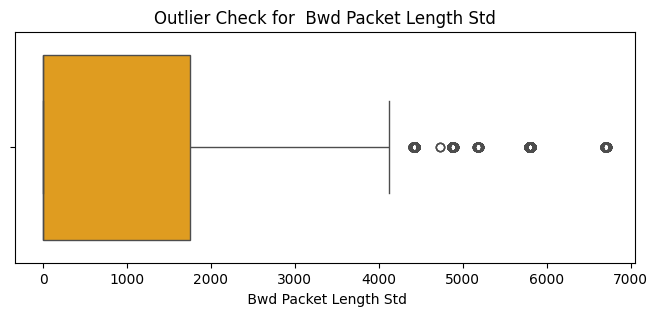

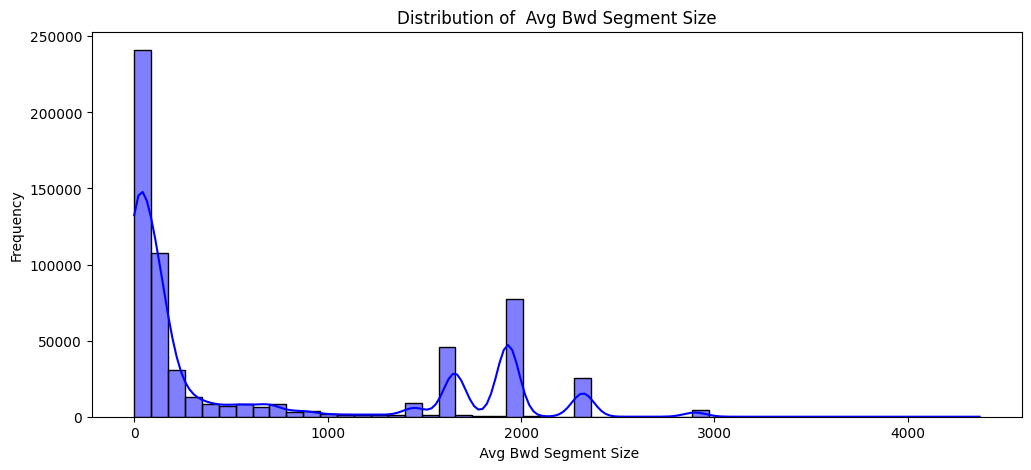

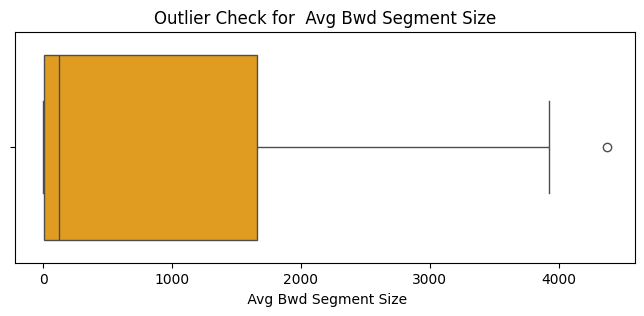

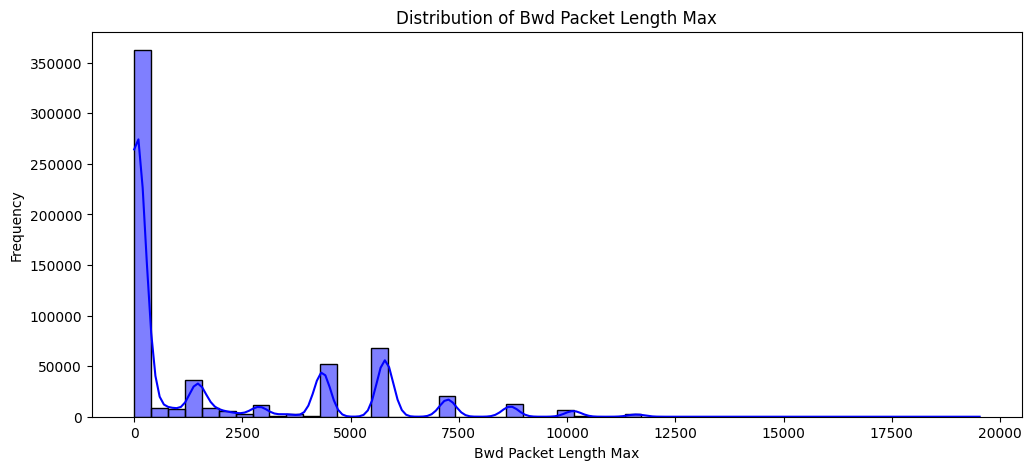

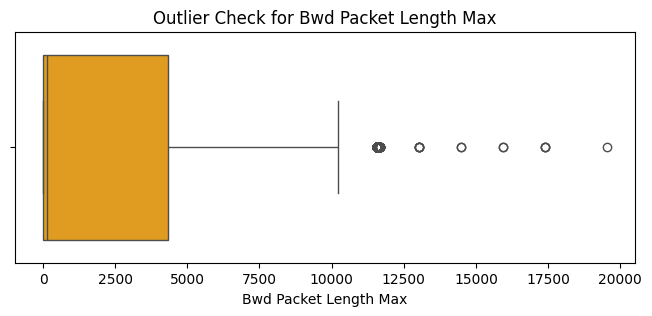

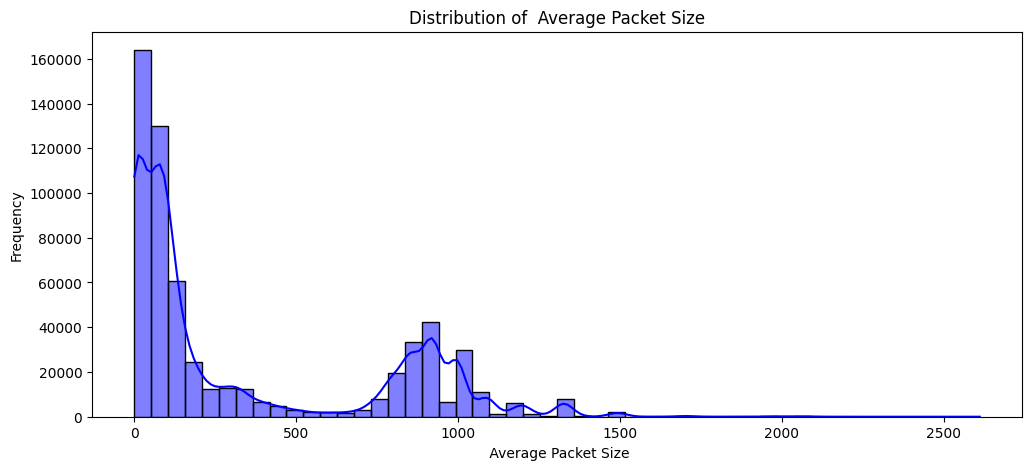

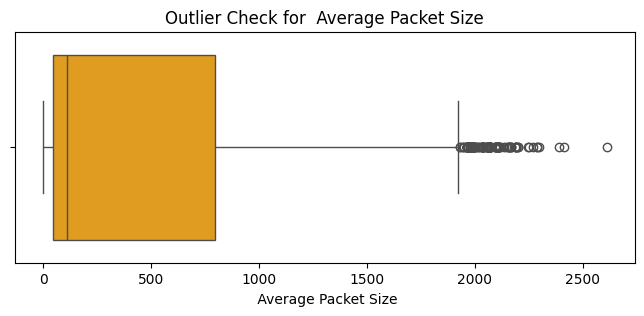

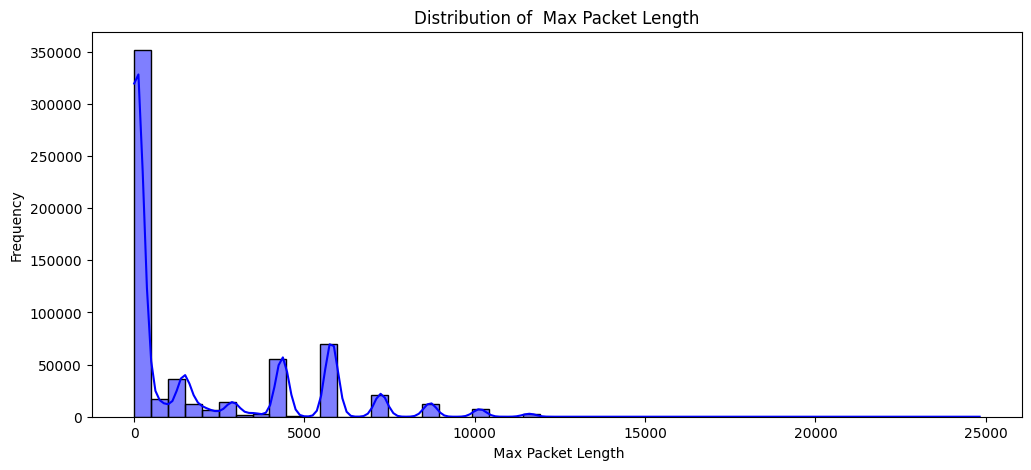

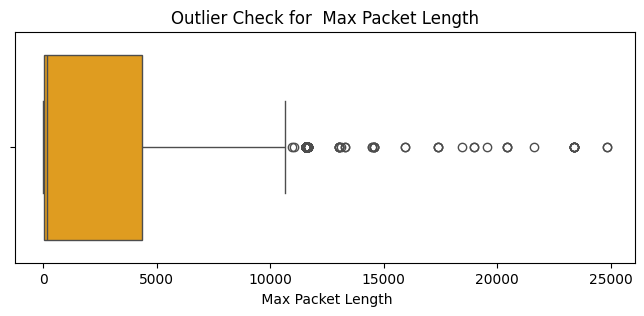

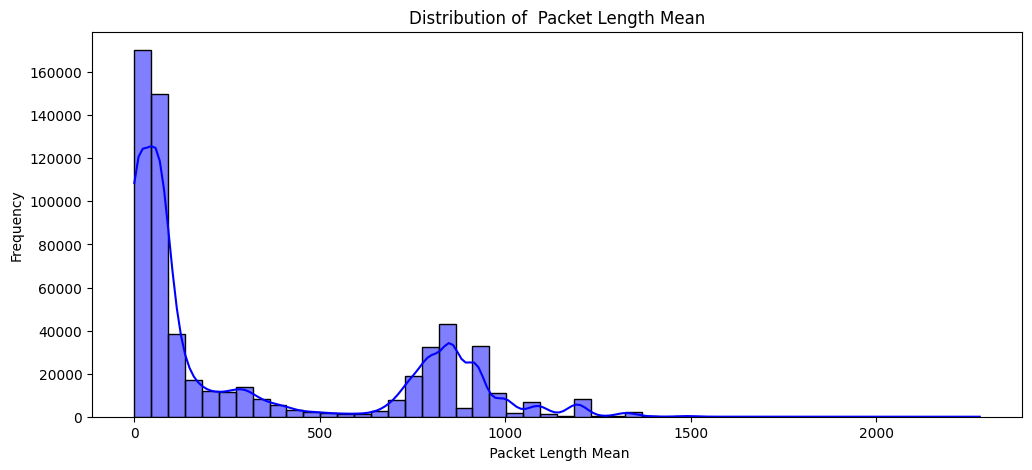

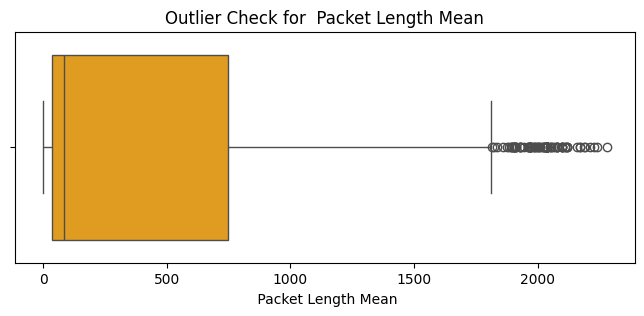

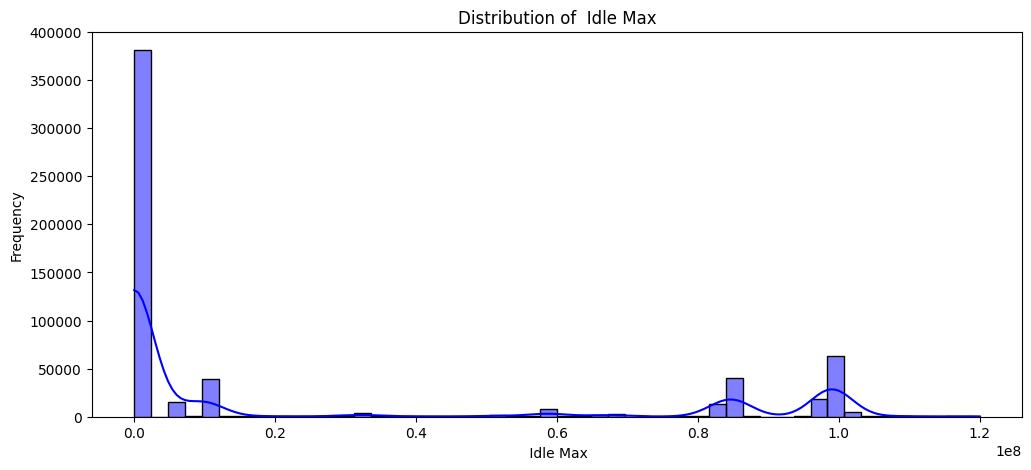

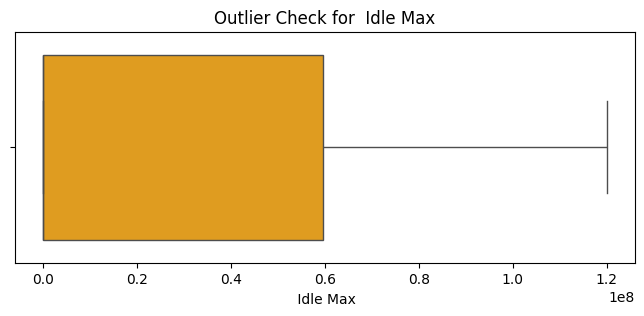

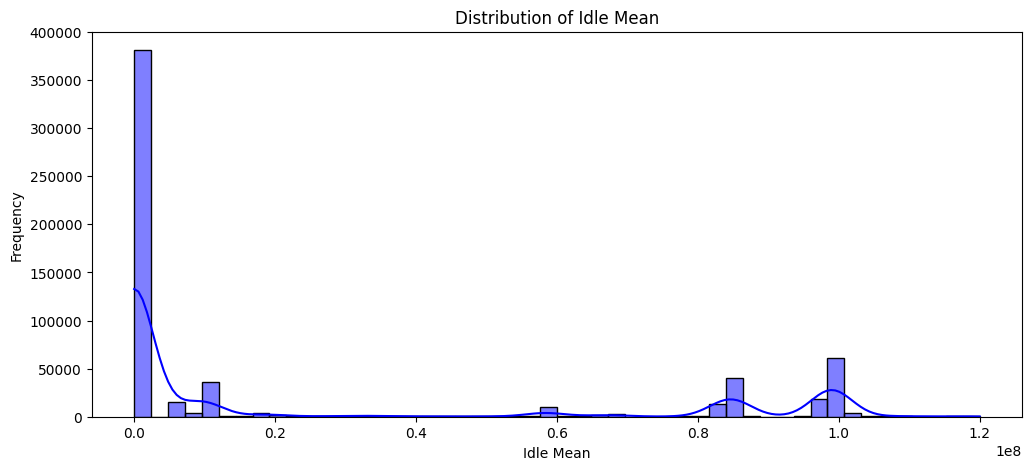

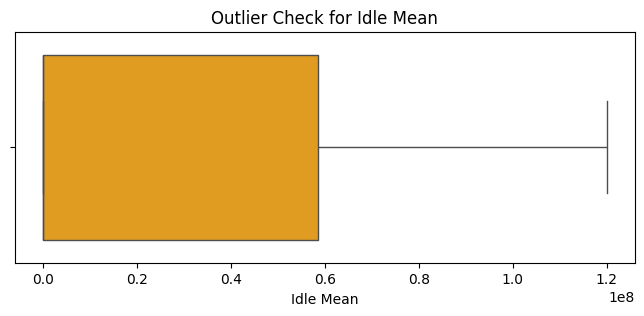

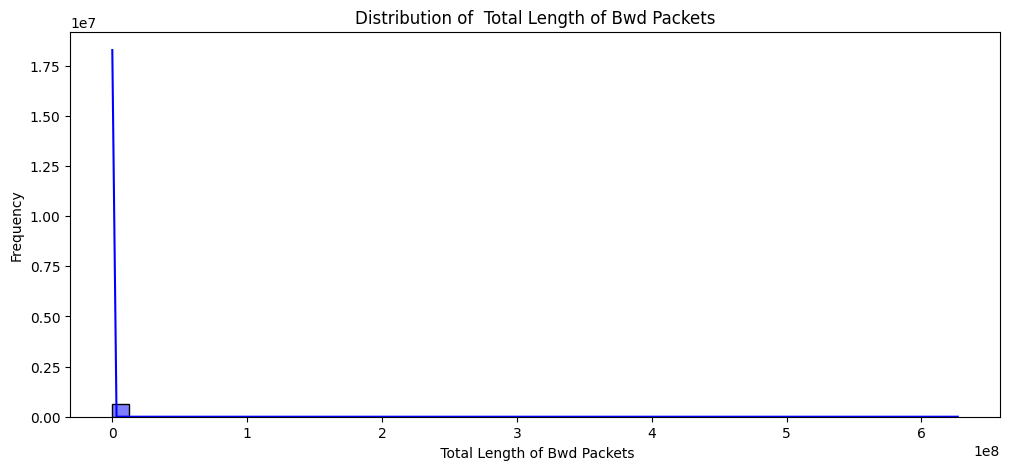

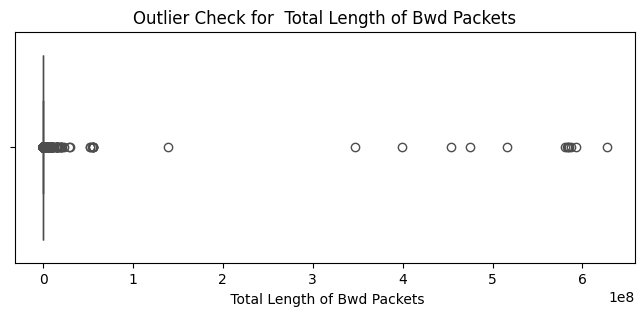

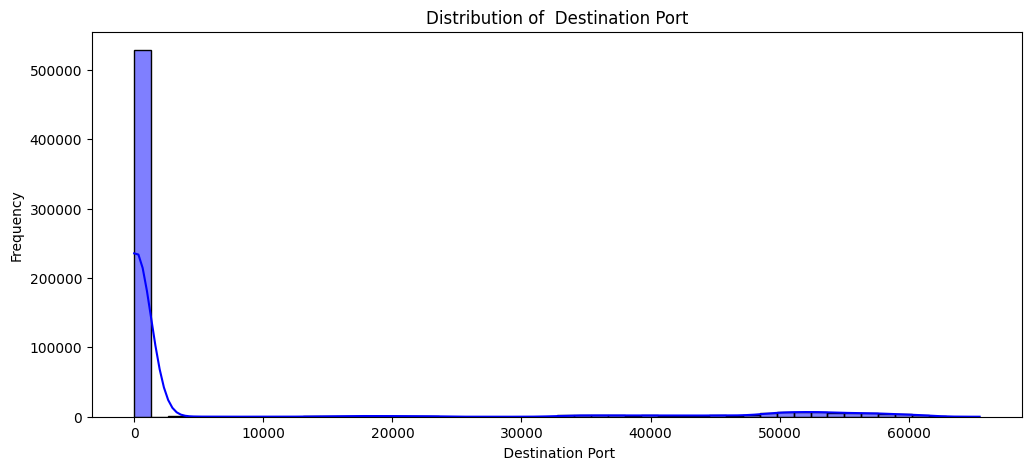

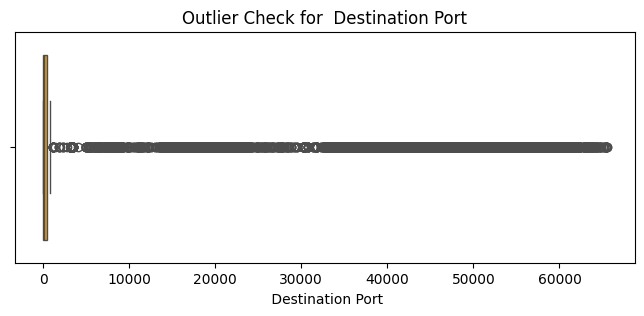

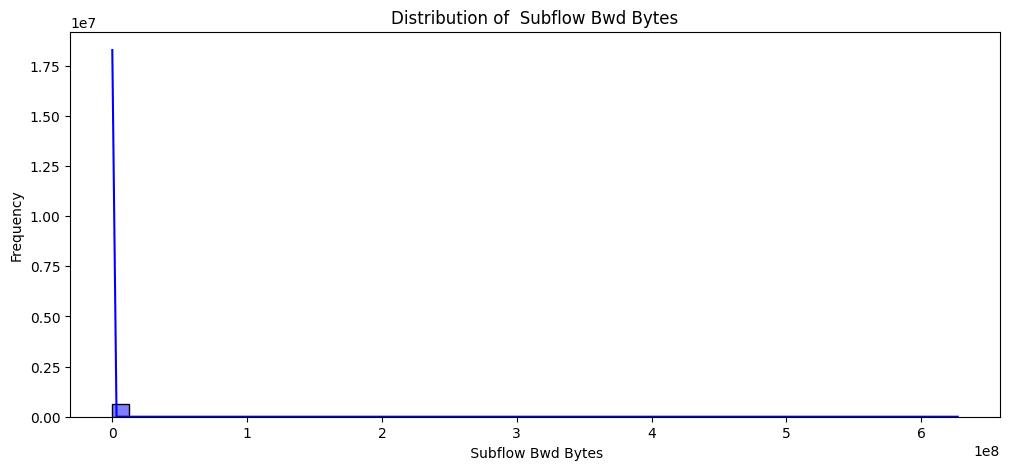

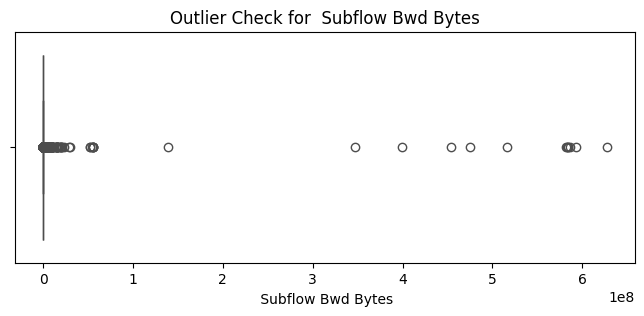

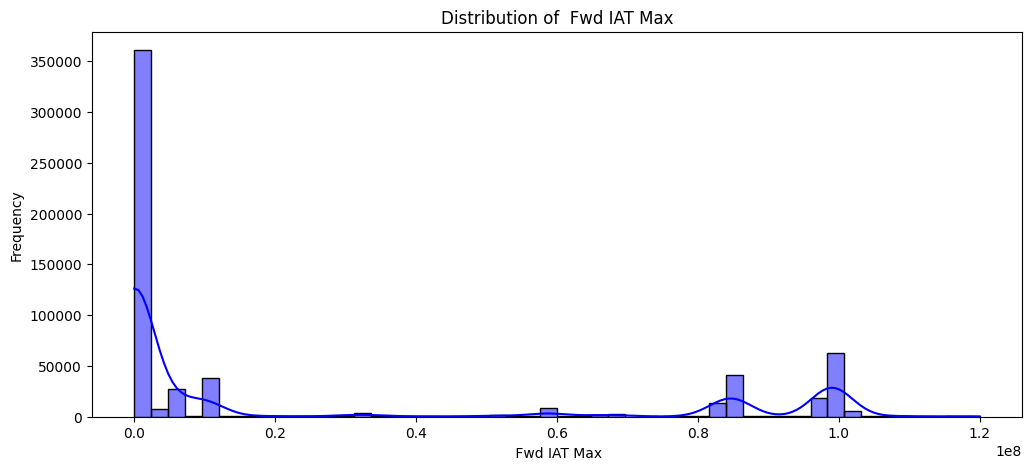

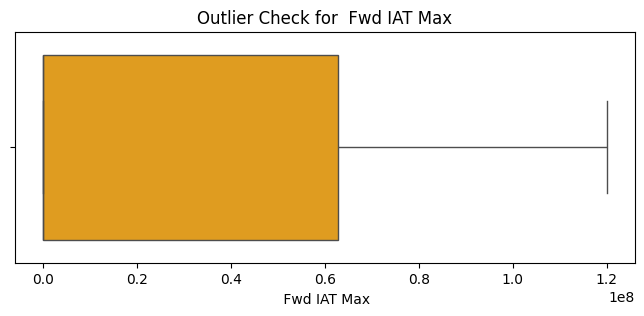

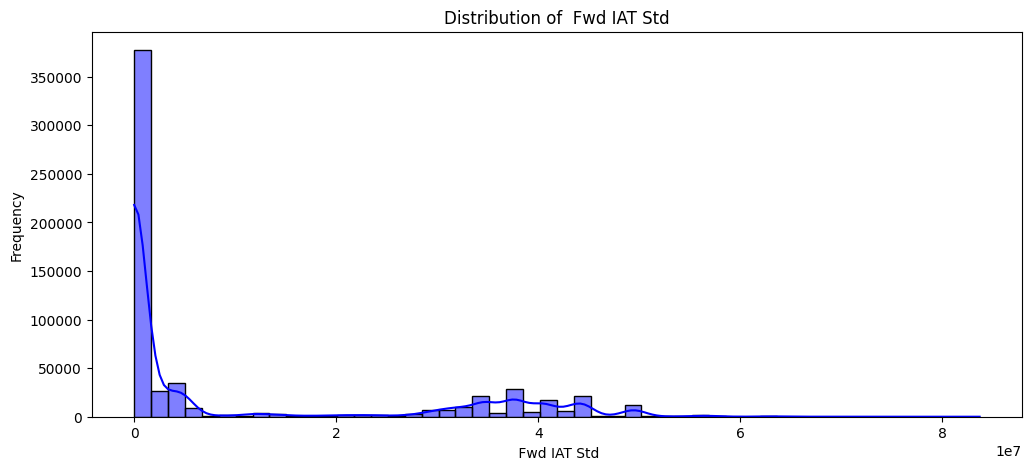

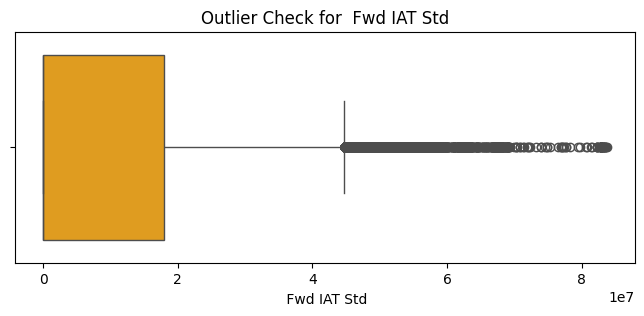

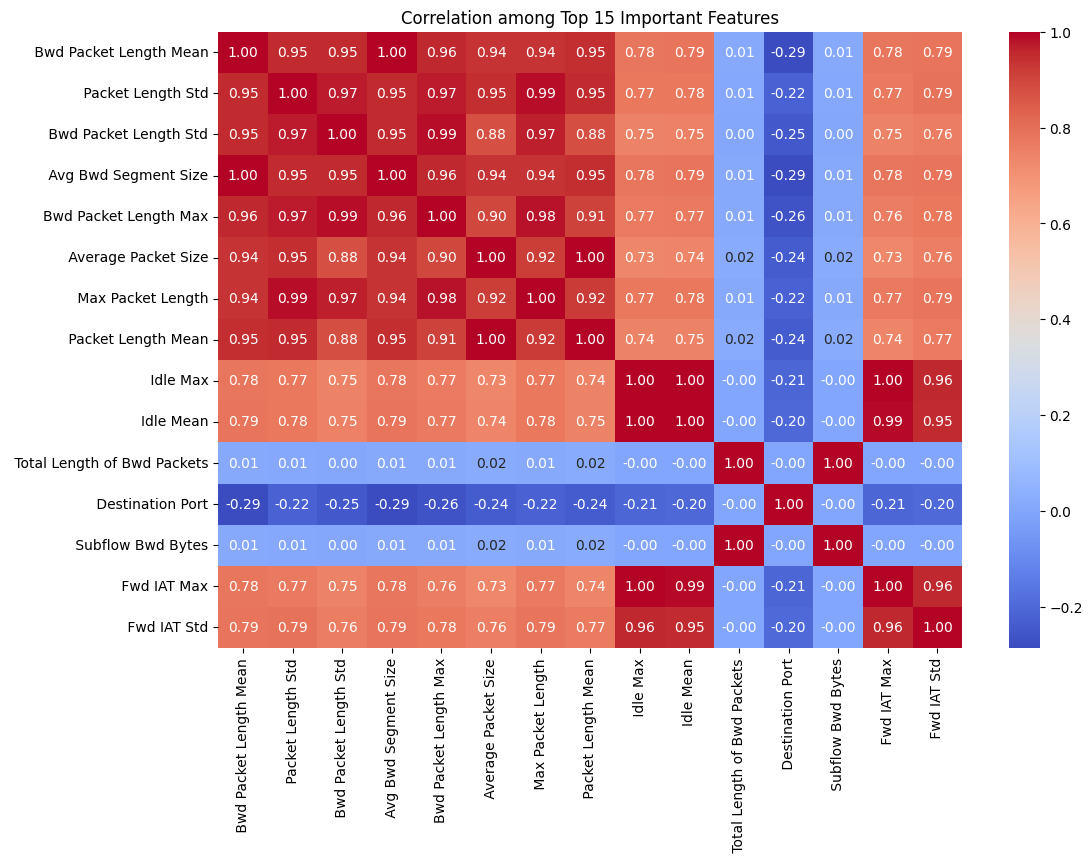

/tmp/ipython-input-2148637700.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[' Label'], palette="viridis")


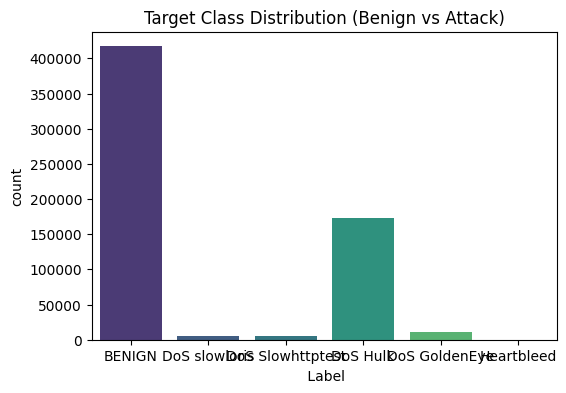

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_15_features = [
    ' Bwd Packet Length Mean', ' Packet Length Std', ' Bwd Packet Length Std',
    ' Avg Bwd Segment Size', 'Bwd Packet Length Max', ' Average Packet Size',
    ' Max Packet Length', ' Packet Length Mean', ' Idle Max', 'Idle Mean',
    ' Total Length of Bwd Packets', ' Destination Port', ' Subflow Bwd Bytes',
    ' Fwd IAT Max', ' Fwd IAT Std'
]


df_top = df[top_15_features]

for col in df_top.select_dtypes(include='number').columns:
    plt.figure(figsize=(12,5))
    sns.histplot(df_top[col], bins=50, kde=True, color="blue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8,3))
    sns.boxplot(x=df_top[col], color="orange")
    plt.title(f"Outlier Check for {col}")
    plt.show()


plt.figure(figsize=(12,8))
sns.heatmap(df_top.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation among Top 15 Important Features")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=df[' Label'], palette="viridis")
plt.title("Target Class Distribution (Benign vs Attack)")
plt.show()


### Explanation
- **Distribution plots (histplot)** show the spread and density of each feature, helping detect skewness or unusual patterns.  
- **Boxplots** highlight outliers, allowing us to assess extreme values that might influence model performance.  
- **Correlation heatmap** identifies relationships among the top features, revealing potential redundancy or multicollinearity.  
- **Target class distribution** confirms the balance between benign and attack classes, essential for classification tasks.  
- Focusing on the top 15 features streamlines analysis and guides model refinement, making the dataset more interpretable and manageable.


Separate Features and Target

In [ ]:
X = df.drop(columns=[' Label'])
y = df[' Label'].apply(lambda x: 0 if x == "BENIGN" else 1)  # binary classification

Separate Features and Target: `X` contains all predictor variables, and `y` is the target, encoded as 0 for BENIGN and 1 for attack.  

Identify Column Types

In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

**Identify Column Types**: Columns are split into numerical and categorical for proper preprocessing.  

Handle Missing Values

In [ ]:
X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].median())
for col in categorical_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

**Handle Missing Values**: Numeric NaNs are replaced with median and categorical NaNs with mode to avoid errors during modeling.  

Encode Categorical Features

In [ ]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

**Encoding**: One-hot encoding converts categorical features to numeric, making them compatible with ML algorithms.  

Check Maximum Values in Numeric Columns

In [ ]:
# Check maximum value in each numeric column
print(X[numerical_cols].max().sort_values(ascending=False).head(10))


 Flow Packets/s                         inf
Flow Bytes/s                            inf
 Subflow Bwd Bytes              627046409.0
 Total Length of Bwd Packets    627000000.0
 Idle Min                       120000000.0
Idle Mean                       120000000.0
 Fwd IAT Mean                   120000000.0
Fwd IAT Total                   120000000.0
 Bwd IAT Max                    120000000.0
 Flow IAT Mean                  120000000.0
dtype: float64


### Explanation
- This step helps **detect extreme values** that might be outliers or require scaling.  
- Sorting in descending order shows the largest numbers first, making it easier to spot anomalies.  
- You can decide to **cap or transform** these values later to reduce skew or improve model performance.


In [ ]:

X[numerical_cols] = X[numerical_cols].replace([np.inf, -np.inf], np.nan)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])


In [ ]:
import numpy as np

X[numerical_cols] = X[numerical_cols].replace([np.inf, -np.inf], np.nan)


X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].median())


 Dimensionality Reduction using PCA

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
print("Shape after PCA:", X_pca.shape)

Shape after PCA: (610794, 21)


In [ ]:
### Explanation
1. **PCA** reduces the number of features while retaining most of the information in the dataset.
2. `n_components=0.95` keeps enough principal components to preserve 95% of the total variance.
3. This helps **speed up model training**, reduce **overfitting**, and simplify the dataset.
4. The resulting `X_pca` is a transformed feature matrix with fewer dimensions, ready for modeling.


Train Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X, y)


RandomForestClassifier(n_estimators=50, random_state=42)

### Explanation
1. **Random Forest** is an ensemble method that combines multiple decision trees to improve predictive performance and reduce overfitting.  
2. `n_estimators=50` means the forest will have 50 trees. Increasing this may improve accuracy but will take longer to train.  
3. `random_state=42` ensures reproducible results.  
4. After `.fit(X, y)`, the model is trained and ready for predictions or evaluation on test data.  
5. You can later use `.predict()` or `.predict_proba()` for predictions and `.feature_importances_` to see which features are most important.


 Feature Importance

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10).index.tolist()
print("Top 10 important features:", top_features)

Top 10 important features: [' Bwd Packet Length Std', 'Bwd Packet Length Max', ' Subflow Bwd Bytes', ' Max Packet Length', ' Avg Bwd Segment Size', ' Bwd Packet Length Mean', ' Total Length of Bwd Packets', ' Flow IAT Mean', ' Flow Packets/s', ' Average Packet Size']


### Explanation
1. **Random Forest Feature Importance** measures how much each feature contributes to reducing impurity in the trees.  
2. `rf_model.feature_importances_` gives a numeric value for each feature, higher means more important.  
3. Sorting and selecting the **top 10 features** helps identify which variables are most predictive.  
4. This information can be used for **feature selection**, **dimensionality reduction**, or **insight analysis**.


In [ ]:
X_top = X[top_features]

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (488635, 10)
Testing set shape: (122159, 10)


### Explanation
1. **Train-Test Split** separates the dataset into a **training set** for model fitting and a **testing set** for evaluation.  
2. `test_size=0.2` means 20% of data is used for testing, 80% for training.  
3. `stratify=y` ensures the proportion of classes in the target variable is the same in both sets.  
4. Using only `X_top` features keeps only the **most important predictors**, improving model efficiency and potentially performance.  
5. This split is now ready for training ML models and evaluating performance.
